# Notebook-base — Random Forest

> **Versão corrigida:** execute as células do início ao fim antes da entrega. Os resultados exibidos foram produzidos pela configuração anterior e devem ser regenerados após as correções metodológicas abaixo.


### Informações do Grupo

##### Grupo: 4

Base: `jena_climate_2009_2016.csv`

Previsão da temperatura do ar na base Jena Climate.

- Granularidade: `horária` (agregação da base original de 10 minutos)
- Variável-alvo: `T (degC)`
- Random State (seed): `42`
- Treino-teste: `80% / 20%`, respeitando a ordem temporal

## Importações e Configurações Padrão 

In [6]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "validacao_bases.py").is_file():
    PROJECT_ROOT = Path("/Users/sofia.santana/Documents/pipeline_ml")
sys.path.insert(0, str(PROJECT_ROOT))

from validacao_bases import carregar_base, relatorios_como_dataframe, validar_base
from funcoes_series_temporais import analisar_componente_residual, calcular_forca_sazonalidade


In [7]:
DATA_FILENAME = "jena_climate_2009_2016.csv"
DATA_PATH = PROJECT_ROOT / "grupo4" / DATA_FILENAME
DATE_COLUMN = "Date Time"
TARGET_COLUMN = "T (degC)"
FREQUENCY = "h"
SEED = 42
TRAIN_RATIO = 0.80
SEASONAL_PERIOD = 24
HORIZON = 24
N_ORIGINS = 12
N_JOBS = -1

## Configuração do Random Forest

In [8]:
# Configuração específica do Random Forest
TARGET_LAGS = [24, 25, 26, 48, 168]
EXOG_COLUMNS = ["p (mbar)", "rh (%)", "wv (m/s)", "wd_sin", "wd_cos"]
EXOG_LAGS = {coluna: [24, 48] for coluna in EXOG_COLUMNS}
ROLLING_WINDOWS = [3, 24, 168]
PARAM_GRID = {
    "n_estimators": [100, 200],
    "max_depth": [10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 1.0],
}
N_JOBS = -1
N_ORIGENS_VALIDACAO = 28
REFIT_EVERY = 1
SAIDA = PROJECT_ROOT / "resultados_random_forest"
SAIDA.mkdir(exist_ok=True)


# 1. Preparação da base

## T01 — Sanitização, valores ausentes e decisões de limpeza

A base original tem registros de 10 minutos e é agregada para a granularidade horária. O marcador `-9999` é convertido para nulo. Para evitar vazamento temporal, a imputação é causal: usa apenas a última observação disponível (`ffill`), limitada a 12 horas; não usa valores posteriores para preencher lacunas. Registros que permanecem nulos após essa janela são removidos na construção das features.

A validação sanitária é somente leitura e registra duplicatas, timestamps ausentes e nulos da base original. Essas ocorrências não são corrigidas silenciosamente: as decisões de tratamento são explícitas no código da etapa T01.

In [9]:
# Validação somente leitura e preparação horária
relatorio = validar_base("clima", raiz=PROJECT_ROOT)
display(relatorios_como_dataframe({"clima": relatorio}))

df_bruto = carregar_base("clima", raiz=PROJECT_ROOT)
df_bruto[DATE_COLUMN] = pd.to_datetime(
    df_bruto[DATE_COLUMN], format="%d.%m.%Y %H:%M:%S", errors="coerce"
)
df_bruto = df_bruto.dropna(subset=[DATE_COLUMN]).sort_values(DATE_COLUMN)
df_bruto = df_bruto.drop_duplicates(subset=DATE_COLUMN).set_index(DATE_COLUMN)

# -9999 é marcador de ausência, não uma medição meteorológica.
df_bruto = df_bruto.replace(-9999, np.nan)
df = df_bruto.select_dtypes(include="number").resample(FREQUENCY).mean()
# Imputação causal limitada: nunca utiliza observações futuras.
df = df.ffill(limit=12)
# Direção do vento é circular: 0° e 360° representam a mesma direção.
df["wd_sin"] = np.sin(np.deg2rad(df["wd (deg)"]))
df["wd_cos"] = np.cos(np.deg2rad(df["wd (deg)"]))
print(f"Base: {DATA_FILENAME} | {len(df):,} observações horárias")
print(f"Período: {df.index.min()} a {df.index.max()}")
print(f"Nulos após imputação causal: {int(df.isna().sum().sum()):,}")


,nome,linhas,colunas,linhas_com_nulos,duplicatas_exatas,datas_invalidas,datas_duplicadas,ordenacao_datas,frequencia_esperada,frequencia_modelagem,frequencia_regular,timestamps_ausentes,timestamps_fora_da_grade,aprovada
0,clima,420551,15,0,327,0,327,não ordenada,10min,h,False,544,0,False


Base: jena_climate_2009_2016.csv | 70,129 observações horárias
Período: 2009-01-01 00:00:00 a 2017-01-01 00:00:00
Nulos após imputação causal: 1,024


## T02 — Dicionário de dados e disponibilidade temporal

Criação do dicionário de dados e análise de disponibilidade temporal das variáveis exógenas para prevenir data leakage.

In [10]:
# Dicionário e disponibilidade temporal das variáveis
DICIONARIO = pd.DataFrame([
    {"variavel": coluna, "tipo": str(df[coluna].dtype),
     "disponibilidade": "observada; usada apenas com defasagens",
     "min": df[coluna].min(), "max": df[coluna].max(), "media": df[coluna].mean()}
    for coluna in [TARGET_COLUMN] + EXOG_COLUMNS
])
display(DICIONARIO.round(3))

,variavel,tipo,disponibilidade,min,max,media
0,T (degC),float64,observada; usada apenas com defasagens,-22.653,37.038,9.443
1,p (mbar),float64,observada; usada apenas com defasagens,934.905,1015.243,989.214
2,rh (%),float64,observada; usada apenas com defasagens,13.683,100.000,76.029
3,wv (m/s),float64,observada; usada apenas com defasagens,0.000,12.895,2.129
4,wd_sin,float64,observada; usada apenas com defasagens,-1.000,1.000,-0.131
5,wd_cos,float64,observada; usada apenas com defasagens,-1.000,1.000,-0.442


## T03 — Análise exploratória visual

Análise visual do alvo e das variáveis exógenas, diagnóstico de outliers e registro das decisões de limpeza.

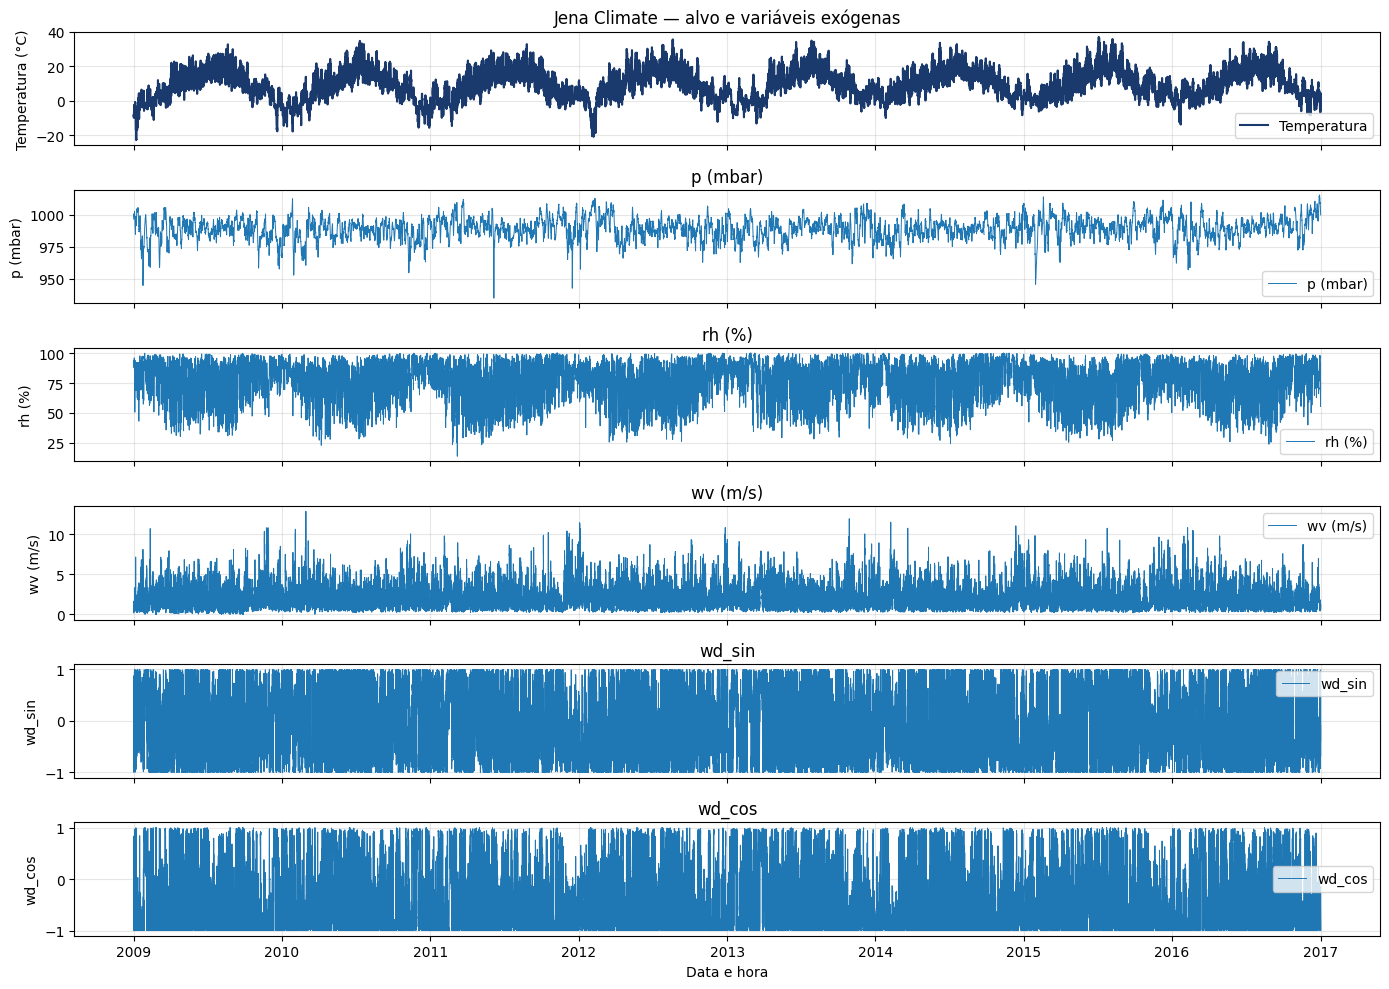

In [11]:
# Análise exploratória visual
fig, axes = plt.subplots(len(EXOG_COLUMNS) + 1, 1, figsize=(14, 10), sharex=True, squeeze=False)
axes = axes[:, 0]
axes[0].plot(df.index, df[TARGET_COLUMN], color="#1a3a6e", label="Temperatura")
axes[0].set_title("Jena Climate — alvo e variáveis exógenas")
axes[0].set_ylabel("Temperatura (°C)")
axes[0].legend(); axes[0].grid(alpha=0.3)
for ax, coluna in zip(axes[1:], EXOG_COLUMNS):
    ax.plot(df.index, df[coluna], linewidth=0.7, label=coluna)
    ax.set_title(coluna); ax.set_ylabel(coluna); ax.legend(); ax.grid(alpha=0.3)
axes[-1].set_xlabel("Data e hora")
plt.tight_layout(); plt.show()

# 2. Sazonalidade

## T04 — Decomposição STL

A STL é calculada com `period=24` para diagnosticar somente o ciclo diário na série horária. A força de tendência deve ser interpretada com cautela: ela pode incorporar variações de prazo mais longo, inclusive a sazonalidade anual, que não é separada por esta decomposição. A sazonalidade anual é representada separadamente pelas features cíclicas de dia do ano.

Força da sazonalidade diária: 0.6923
Força de tendência (pode incluir variação anual): 0.9581


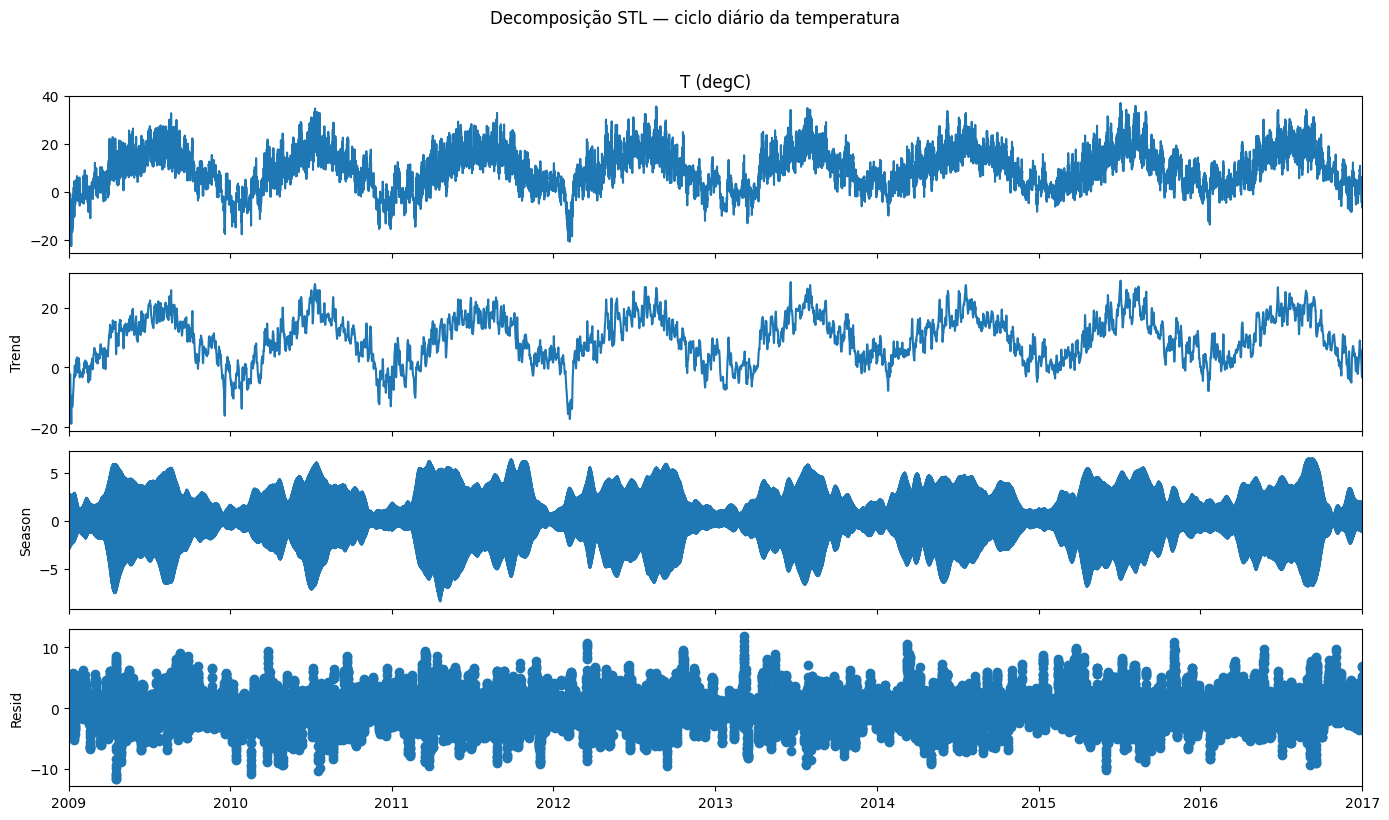

In [12]:
# Decomposição STL com período diário
stl_resultado = calcular_forca_sazonalidade(df[TARGET_COLUMN], periodo=SEASONAL_PERIOD)
decomposicao = stl_resultado["decomposicao"]
print(f"Força da sazonalidade diária: {stl_resultado['forca_sazonalidade']:.4f}")
print(
    "Força de tendência (pode incluir variação anual): "
    f"{stl_resultado['forca_tendencia']:.4f}"
)
fig = decomposicao.plot(); fig.set_size_inches(14, 8)
fig.suptitle("Decomposição STL — ciclo diário da temperatura", y=1.02)
plt.tight_layout(); plt.show()

## T05 — Força da sazonalidade e resíduos

A força sazonal indica quanto o componente diário reduz a variância residual. O componente residual é avaliado por média, dispersão e Ljung–Box. Autocorrelação residual não implica sozinha falha do Random Forest: os erros dos 24 passos de uma mesma origem compartilham o mesmo estado de informação e podem ser dependentes.

In [13]:
# Força sazonal e componente residual
analise_residuos_stl = analisar_componente_residual(decomposicao, lags=24)
print(f"Média do residual: {analise_residuos_stl['media']:.6f}")
print(f"Desvio-padrão do residual: {analise_residuos_stl['desvio_padrao']:.6f}")
display(analise_residuos_stl["autocorrelacao_residual"])


Média do residual: -0.035397
Desvio-padrão do residual: 1.646806


,lb_stat,lb_pvalue
1,59765.375599,0.0
2,102713.998140,0.0
3,129801.638482,0.0
4,144355.449710,0.0
5,150526.019282,0.0
6,152160.896863,0.0
7,152221.907156,0.0
8,152560.958554,0.0
9,154024.124751,0.0
10,156677.583596,0.0


# 3. Features e validação

## T06 — Pipeline de features

Construção do pipeline de features com lags do alvo e das exógenas, janelas móveis, variáveis de calendário e encoding cíclico.

In [14]:
# Construção das features sem informação futura para HORIZON passos
features = pd.DataFrame(index=df.index)
for lag in TARGET_LAGS:
    features[f"target_lag_{lag}"] = df[TARGET_COLUMN].shift(lag)
for coluna, lags in EXOG_LAGS.items():
    for lag in lags:
        features[f"{coluna}_lag_{lag}"] = df[coluna].shift(lag)
for janela in ROLLING_WINDOWS:
    features[f"target_roll_mean_{janela}"] = (
        df[TARGET_COLUMN].shift(HORIZON).rolling(janela).mean()
    )
    features[f"target_roll_std_{janela}"] = (
        df[TARGET_COLUMN].shift(HORIZON).rolling(janela).std()
    )
# Calendário é conhecido antecipadamente e pode ser usado no horizonte futuro.
features["hora_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
features["hora_cos"] = np.cos(2 * np.pi * df.index.hour / 24)
features["dia_semana_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
features["dia_semana_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)
features["dia_ano_sin"] = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
features["dia_ano_cos"] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)
model_data = pd.concat([df[TARGET_COLUMN].rename("target"), features], axis=1).dropna()
print(f"Features criadas: {features.shape[1]} | observações utilizáveis: {len(model_data):,}")


Features criadas: 27 | observações utilizáveis: 69,513


## T07 — Escalonamento por janela

O Random Forest não exige escalonamento: as árvores usam pontos de corte e são invariantes à escala das variáveis. A separação temporal permanece necessária para evitar que informações do futuro participem do treinamento.

In [15]:
# Divisão temporal
n_train = int(len(model_data) * TRAIN_RATIO)
train = model_data.iloc[:n_train]
test = model_data.iloc[n_train:]
y_train = train["target"]
y_test = test["target"]
X_train = train.drop(columns="target")
X_test = test.drop(columns="target")
print(f"Treino: {len(train):,} ({len(train) / len(model_data):.1%})")
print(f"Teste: {len(test):,} ({len(test) / len(model_data):.1%})")

Treino: 55,610 (80.0%)
Teste: 13,903 (20.0%)


## T08 — Validação walk-forward

Implementação do protocolo walk-forward com janelas, origens de teste fixas e horizonte de previsão unificado.

In [16]:
# Origens em todo o bloco de teste; uma origem por bloco de HORIZON horas.
origens_teste = list(
    range(len(train), len(model_data) - HORIZON + 1, HORIZON)
)
datas_origem = pd.DataFrame({
    "origem_idx": origens_teste,
    "data_origem": [model_data.index[o - 1] for o in origens_teste],
    "primeiro_alvo": [model_data.index[o] for o in origens_teste],
    "ultimo_alvo": [model_data.index[o + HORIZON - 1] for o in origens_teste],
})
display(datas_origem.head())
print(f"Origens de teste: {len(origens_teste)} | horizonte: {HORIZON} horas")
print(f"Primeira origem está no teste? {origens_teste[0] >= len(train)}")
print(f"Último alvo: {datas_origem.iloc[-1]['ultimo_alvo']}")
print("Refit a cada origem: a janela de treino é expansiva e incorpora apenas dados já observados.")


,origem_idx,data_origem,primeiro_alvo,ultimo_alvo
0,55610,2015-05-22 05:00:00,2015-05-22 06:00:00,2015-05-23 05:00:00
1,55634,2015-05-23 05:00:00,2015-05-23 06:00:00,2015-05-24 05:00:00
2,55658,2015-05-24 05:00:00,2015-05-24 06:00:00,2015-05-25 05:00:00
3,55682,2015-05-25 05:00:00,2015-05-25 06:00:00,2015-05-26 05:00:00
4,55706,2015-05-26 05:00:00,2015-05-26 06:00:00,2015-05-27 05:00:00


Origens de teste: 579 | horizonte: 24 horas
Primeira origem está no teste? True
Último alvo: 2016-12-31 17:00:00
Refit a cada origem: a janela de treino é expansiva e incorpora apenas dados já observados.


# 4. Modelagem Random Forest

## T11 — Otimização do Random Forest

Otimização de n_estimators, max_depth, min_samples_split, min_samples_leaf e max_features usando somente dados de desenvolvimento. A validação usa 28 origens walk-forward de 24 horas, anteriores ao teste final; os hiperparâmetros selecionados são congelados antes da avaliação fora da amostra.


In [17]:
# Grid com validação em blocos de 24 horas
inicio_grid = time.perf_counter()
# A validação usa as últimas origens do treino, mas com a mesma tarefa final:
# cada origem prevê HORIZON passos e o MAE é agregado entre os blocos.
origens_validacao = list(
    range(
        len(y_train) - N_ORIGENS_VALIDACAO * HORIZON,
        len(y_train),
        HORIZON,
    )
)
parametros = list(ParameterGrid(PARAM_GRID))
resultados_grid = []
print(f"Origens de validação: {len(origens_validacao)}")
print(f"Combinações no grid: {len(parametros)}")

X_model = model_data.drop(columns="target")
y_model = model_data["target"]
for grid_index, params in enumerate(parametros):
    erros_validacao = []
    for origem in origens_validacao:
        modelo_grid = RandomForestRegressor(
            **params, random_state=SEED, n_jobs=N_JOBS
        )
        modelo_grid.fit(X_model.iloc[:origem], y_model.iloc[:origem])
        previsao = modelo_grid.predict(
            X_model.iloc[origem:origem + HORIZON]
        )
        real = y_model.iloc[origem:origem + HORIZON]
        erros_validacao.extend(real.to_numpy() - previsao)
    resultados_grid.append({
        "grid_index": grid_index,
        **params,
        "MAE_validacao": np.abs(erros_validacao).mean(),
        "RMSE_validacao": np.sqrt(np.mean(np.square(erros_validacao))),
        "n_origins_validacao": len(origens_validacao),
    })
    print(f"{grid_index + 1}/{len(parametros)} combinações testadas", end="\r")

df_grid = pd.DataFrame(resultados_grid).sort_values("MAE_validacao").reset_index(drop=True)
print("\nMelhores configurações:")
display(df_grid.head(10))
melhor_indice = int(df_grid.loc[0, "grid_index"])
melhor_params = parametros[melhor_indice]
BEST_PARAMS = melhor_params.copy()
print("Hiperparâmetros congelados:", BEST_PARAMS)
tempo_grid = time.perf_counter() - inicio_grid
print(f"Tempo do grid: {tempo_grid / 60:.2f} minutos")
df_grid.to_csv(SAIDA / "grid_random_forest_grupo4.csv", index=False)

Origens de validação: 28
Combinações no grid: 48


KeyboardInterrupt: 

## T12 — Random Forest walk-forward

Treinamento e execução walk-forward do Random Forest com hiperparâmetros congelados, gerando previsões e resíduos.

In [ ]:
# Walk-forward expansivo em todo o teste: um refit por origem.
inicio_walk_forward = time.perf_counter()
registros = []
for bloco, origem in enumerate(origens_teste):
    modelo_wf = RandomForestRegressor(
        **BEST_PARAMS, random_state=SEED, n_jobs=N_JOBS
    )
    modelo_wf.fit(X_model.iloc[:origem], y_model.iloc[:origem])
    X_futuro = X_model.iloc[origem:origem + HORIZON]
    y_futuro = y_model.iloc[origem:origem + HORIZON]
    previsao = modelo_wf.predict(X_futuro)
    for passo, (data, real, previsto) in enumerate(
        zip(y_futuro.index, y_futuro, previsao), start=1
    ):
        registros.append({
            "modelo": "Random Forest",
            "origem": model_data.index[origem - 1],
            "data": data,
            "passo": passo,
            "real": real,
            "previsto": previsto,
            "residuo": real - previsto,
        })
    print(f"Origem {bloco + 1}/{len(origens_teste)} concluída", end="\r")
wf = pd.DataFrame(registros)
tempo_walk_forward = time.perf_counter() - inicio_walk_forward
print(f"\nPrevisões walk-forward registradas: {len(wf):,}")
print(f"Tempo do walk-forward: {tempo_walk_forward / 60:.2f} minutos")
print(f"Refits realizados: {len(origens_teste)}")
wf.to_csv(SAIDA / "previsoes_random_forest_grupo4.csv", index=False)


# 5. Avaliação

## T16 — Comparação por MAE

Consolidação do MAE fora da amostra por base e modelo, incluindo número de vitórias e posição média.

In [51]:
# Métricas fora da amostra
metricas = pd.DataFrame([{
    "base": "clima",
    "modelo": "Random Forest",
    "MAE": wf["residuo"].abs().mean(),
    "RMSE": np.sqrt((wf["residuo"] ** 2).mean()),
    "ME_vies": wf["residuo"].mean(),
    "MaxAE": wf["residuo"].abs().max(),
    "tempo_grid_min": tempo_grid / 60,
    "tempo_walk_forward_min": tempo_walk_forward / 60,
}])
display(metricas.round(4))
print("MAE por passo do horizonte:")
mae_por_passo = wf.groupby("passo")["residuo"].apply(lambda s: s.abs().mean()).round(4)
display(mae_por_passo)
metricas.to_csv(SAIDA / "metricas_random_forest_grupo4.csv", index=False)
mae_por_passo.rename("MAE").to_csv(SAIDA / "mae_por_passo_random_forest_grupo4.csv")

,base,modelo,MAE,RMSE,ME_vies,MaxAE,tempo_grid_min,tempo_walk_forward_min
0,clima,Random Forest,2.3336,2.9727,0.1709,11.2954,90.4905,7.7993


MAE por passo do horizonte:


passo
1     2.1019
2     2.1772
3     2.2399
4     2.3885
5     2.4734
6     2.4885
7     2.5329
8     2.5365
9     2.5690
10    2.6140
11    2.5924
12    2.5819
13    2.5078
14    2.4192
15    2.2890
16    2.2087
17    2.1264
18    2.1177
19    2.1317
20    2.1127
21    2.1452
22    2.2245
23    2.2202
24    2.2067
Name: residuo, dtype: float64

## T17 — Diagnóstico dos resíduos

Análise gráfica e estatística dos resíduos com série temporal dos erros, ACF, teste de Ljung-Box e tabela de p-valores.

In [ ]:
# Diagnóstico dos resíduos fora da amostra por horizonte.
# Erros de passos diferentes não são combinados no Ljung-Box, pois têm dinâmicas distintas.
passos_diagnostico = [1, 12, 24]
passo_grafico = 1
residuos = (
    wf.loc[wf["passo"] == passo_grafico]
    .sort_values("data")
    .set_index("data")["residuo"]
)
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
axes[0].plot(residuos.index, residuos, label=f"Resíduo — passo {passo_grafico}")
axes[0].axhline(0, color="black", linestyle="--", label="Erro zero")
axes[0].set_title(f"Resíduos walk-forward — Random Forest (passo {passo_grafico})")
axes[0].set_ylabel("Erro (°C)"); axes[0].set_xlabel("Data e hora")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(residuos, bins=30, alpha=0.75, label="Resíduos")
axes[1].set_title(f"Distribuição dos resíduos — passo {passo_grafico}")
axes[1].set_xlabel("Erro (°C)"); axes[1].set_ylabel("Frequência")
axes[1].legend(); axes[1].grid(alpha=0.3)
plot_acf(residuos, lags=min(48, len(residuos) // 5), ax=axes[2], title=f"ACF dos resíduos — passo {passo_grafico}")
axes[2].set_xlabel("Defasagem (lag)"); axes[2].set_ylabel("Autocorrelação")
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

resultados_ljung_box = []
for passo in passos_diagnostico:
    residuos_passo = (
        wf.loc[wf["passo"] == passo]
        .sort_values("data")["residuo"]
        .dropna()
    )
    lb = acorr_ljungbox(
        residuos_passo,
        lags=range(1, min(24, len(residuos_passo) - 1) + 1),
        return_df=True,
    ).reset_index(names="lag")
    lb.insert(0, "passo", passo)
    resultados_ljung_box.append(lb)
ljung_box = pd.concat(resultados_ljung_box, ignore_index=True)
display(ljung_box)
resumo_residuos = wf.groupby("passo")["residuo"].agg(["mean", "std"])
display(resumo_residuos.loc[passos_diagnostico])
print("ME > 0 indica subestimação média; ME < 0, superestimação média.")
print("Ljung-Box e ACF devem ser interpretados por passo do horizonte, não com passos misturados.")
ljung_box.to_csv(SAIDA / "ljung_box_random_forest_grupo4.csv", index=False)


## T18 — Importância das features

Cálculo e interpretação da importância das features: permutation importance para modelos de tabela e coeficientes para o SARIMAX.

In [ ]:
# Importância nativa agregada em modelos treinados no mesmo protocolo expansivo.
# A amostra de origens cobre o período de teste e usa somente dados disponíveis em cada origem.
n_origens_importancia = min(36, len(origens_teste))
indices_importancia = np.unique(
    np.linspace(0, len(origens_teste) - 1, n_origens_importancia, dtype=int)
)
importancias_origem = []
for indice in indices_importancia:
    origem = origens_teste[indice]
    modelo_importancia = RandomForestRegressor(
        **BEST_PARAMS, random_state=SEED, n_jobs=N_JOBS
    )
    modelo_importancia.fit(X_model.iloc[:origem], y_model.iloc[:origem])
    importancias_origem.append(modelo_importancia.feature_importances_)

matriz_importancias = np.vstack(importancias_origem)
importancias = pd.DataFrame({
    "feature": X_model.columns,
    "importancia_media": matriz_importancias.mean(axis=0),
    "desvio_padrao_entre_origens": matriz_importancias.std(axis=0),
})
importancias["tipo"] = np.where(
    importancias["feature"].str.contains("_lag_"), "lag/exógena", "calendário/janela"
)
importancias = importancias.sort_values("importancia_media", ascending=False)
display(importancias.head(20))

top = importancias.head(15).sort_values("importancia_media")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top["feature"],
    top["importancia_media"],
    xerr=top["desvio_padrao_entre_origens"],
    label="Média entre origens",
)
ax.set_title("Importância nativa das features — Random Forest")
ax.set_xlabel("Importância média")
ax.set_ylabel("Feature")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
importancias.to_csv(SAIDA / "importancia_random_forest_grupo4.csv", index=False)
print("A importância é associativa, não causal; lags correlacionados podem dividir relevância entre si.")
